In [1]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

# Add project root to path to import util and plotting modules
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
import plotting.plotting_style as plt
from plotting.plotting_style import rgb
import plotting.plotting_style


# Load the data
df = util.load_data()
df

{'font.size': 8, 'axes.labelsize': 8, 'legend.fontsize': 6, 'xtick.labelsize': 6, 'ytick.labelsize': 6, 'axes.titlesize': 8}


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,Sprint
...,...,...,...,...,...,...,...,...,...,...,...,...,...
224406,2023,W,Frauen,Speerwurf,44.25,NaN,Lara Siemer,2002,TSV Bayer o4 Leverkusen,21.05.2023,Filderstadt,788,Throw
224407,2023,W,Frauen,Speerwurf,44.08,NaN,Anna Neubert,2003,1. LAV Rostock,03.09.2023,Hannover,784,Throw
224408,2023,W,Frauen,Speerwurf,43.87,NaN,Sandrina Sprengel,2004,LG Steinlach-Zollern,21.05.2023,Filderstadt,781,Throw
224409,2023,W,Frauen,Speerwurf,43.86,NaN,Nele Ganssmueller,2004,LG Fichtelgebirge,26.02.2023,Halle (Saale),780,Throw


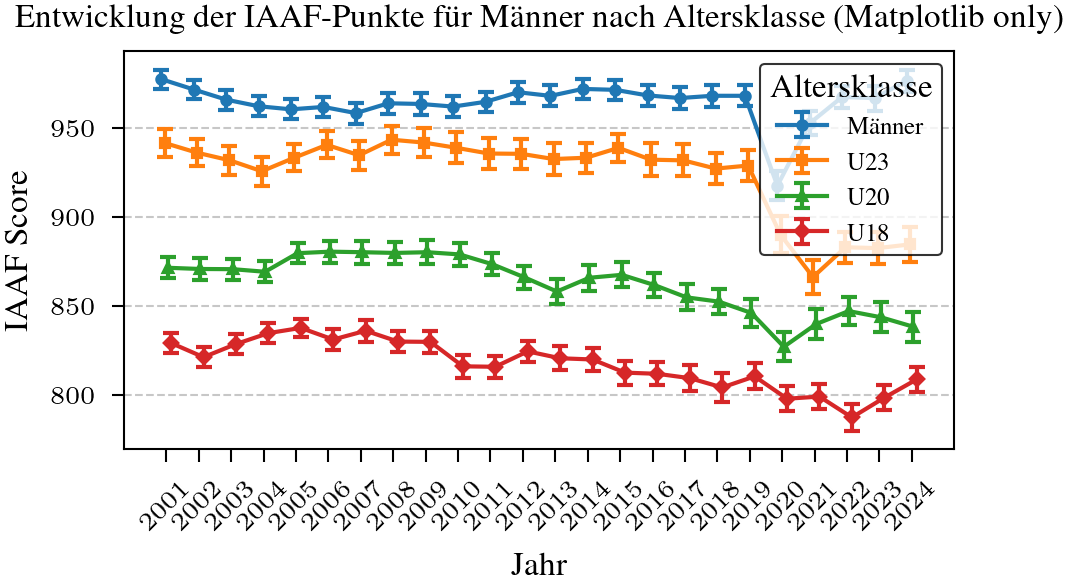

In [15]:

# Load the dataframe

# Data Cleaning
df['iaaf_score'] = pd.to_numeric(df['iaaf_score'], errors='coerce')
df = df.dropna(subset=['iaaf_score', 'jahr'])

# Filter for Men
df_men = df[df['geschlecht'].isin(['M', 'm'])].copy()

# Map the raw values to the desired labels
age_mapping = {
    'Maenner': 'Männer',
    'U23': 'U23',
    '20': 'U20',
    '18': 'U18'
}

# Filter for the keys in our mapping
df_men_filtered = df_men[df_men['altersklasse'].isin(age_mapping.keys())].copy()
df_men_filtered['altersklasse_label'] = df_men_filtered['altersklasse'].map(age_mapping)

# Calculate Mean and CI manually
# Group by year and age class
stats = df_men_filtered.groupby(['jahr', 'altersklasse_label'])['iaaf_score'].agg(['mean', 'std', 'count']).reset_index()

# Calculate 95% Confidence Interval (margin of error)
# Margin = 1.96 * (std / sqrt(count))
stats['ci'] = 1.96 * (stats['std'] / np.sqrt(stats['count']))

# Define order for plotting and colors
age_groups = ['Männer', 'U23', 'U20', 'U18']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Standard matplotlib colors
markers = ['o', 's', '^', 'D']

# Plotting with Matplotlib
# plt.figure(figsize=(15, 8))
ax = plt.gca()

# Offset for dodge effect (to avoid overlapping error bars)
offsets = np.linspace(-0.15, 0.15, len(age_groups))

for i, age_group in enumerate(age_groups):
    group_data = stats[stats['altersklasse_label'] == age_group].sort_values('jahr')
    
    if not group_data.empty:
        # Add slight offset to x values for visual clarity (dodging)
        x_values = group_data['jahr'] + offsets[i]
        
        plt.errorbar(
            x=x_values, 
            y=group_data['mean'], 
            yerr=group_data['ci'], 
            label=age_group,
            fmt=markers[i] + '-', # Marker and line style
            
            capsize=2,
            markersize=2,
            color=colors[i]
        )

plt.title('Entwicklung der IAAF-Punkte für Männer nach Altersklasse (Matplotlib only)')
plt.ylabel('IAAF Score')
plt.xlabel('Jahr')
# only use every second year for x-ticks

# Set x-ticks to be integers (years)
years = sorted(df_men_filtered['jahr'].unique())
plt.xticks(years, rotation=45)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Altersklasse')